Phase noise is a critical impairment in wireless systems, essentially representing random fluctuations in the phase of a waveform. In the context of Amplitude Modulation (AM), while the primary information is carried in the envelope, phase noise from the local oscillators can still cause significant issues, particularly during downconversion or when dealing with coherent detection.



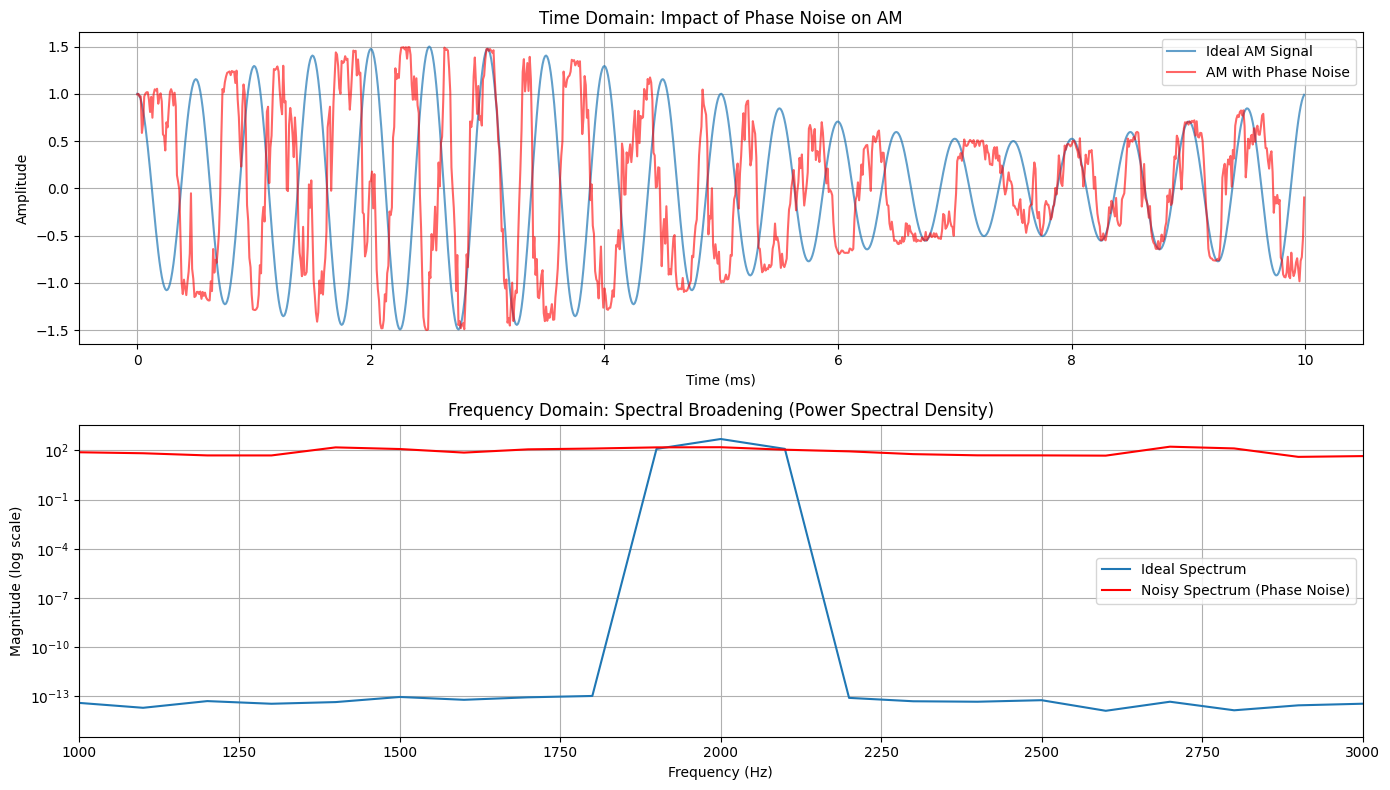

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Parameters
fs = 100000          # Sampling frequency (Hz)
t = np.arange(0, 0.01, 1/fs)  # Time vector (10ms)
fc = 2000            # Carrier frequency (Hz)
fm = 100             # Message frequency (Hz)
mu = 0.5             # Modulation index

# 2. Generate Signals
# Message signal (Simple sine wave)
message = np.sin(2 * np.pi * fm * t)

# Ideal Carrier
carrier_ideal = np.cos(2 * np.pi * fc * t)

# 3. Model Phase Noise
# Phase noise is often modeled as a random walk (Wiener process)
# sigma represents the severity of the phase noise
sigma = 0.3
phase_noise = np.cumsum(np.random.normal(0, sigma, len(t)))

# Carrier with Phase Noise
carrier_noisy = np.cos(2 * np.pi * fc * t + phase_noise)

# 4. Amplitude Modulation (Double Sideband Full Carrier)
am_ideal = (1 + mu * message) * carrier_ideal
am_noisy = (1 + mu * message) * carrier_noisy

# 5. Frequency Domain Analysis
def get_spectrum(signal, fs):
    fft_val = np.fft.fft(signal)
    freqs = np.fft.fftfreq(len(signal), 1/fs)
    return freqs[:len(freqs)//2], np.abs(fft_val[:len(fft_val)//2])

freqs, spec_ideal = get_spectrum(am_ideal, fs)
_, spec_noisy = get_spectrum(am_noisy, fs)

# 6. Plotting
plt.figure(figsize=(14, 8))

# Time Domain Plot
plt.subplot(2, 1, 1)
plt.plot(t*1000, am_ideal, label='Ideal AM Signal', alpha=0.7)
plt.plot(t*1000, am_noisy, label='AM with Phase Noise', color='red', alpha=0.6)
plt.title('Time Domain: Impact of Phase Noise on AM')
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

# Frequency Domain Plot (Zoomed in on carrier)
plt.subplot(2, 1, 2)
plt.semilogy(freqs, spec_ideal, label='Ideal Spectrum')
plt.semilogy(freqs, spec_noisy, label='Noisy Spectrum (Phase Noise)', color='red')
plt.title('Frequency Domain: Spectral Broadening (Power Spectral Density)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (log scale)')
plt.xlim(fc - 1000, fc + 1000)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

The IQ Plot (Top Right): In a perfect AM system, the signal should be a straight horizontal line on the X-axis (the I-axis), because AM shouldn't have any vertical (Q-axis) component. The red "arc" or "fan" shape you see is the phase noise literally pushing the signal off its intended path.

The Phase Drift (Top Left): This shows you exactly how much the local oscillator's "clock" is wandering away from the truth over just a few milliseconds.

The Zero-Crossings (Bottom): If you look closely at the red vs. blue lines, they no longer cross the zero-line at the same time. In a real receiver, this "timing jitter" makes it very hard for the hardware to stay locked onto the signal.


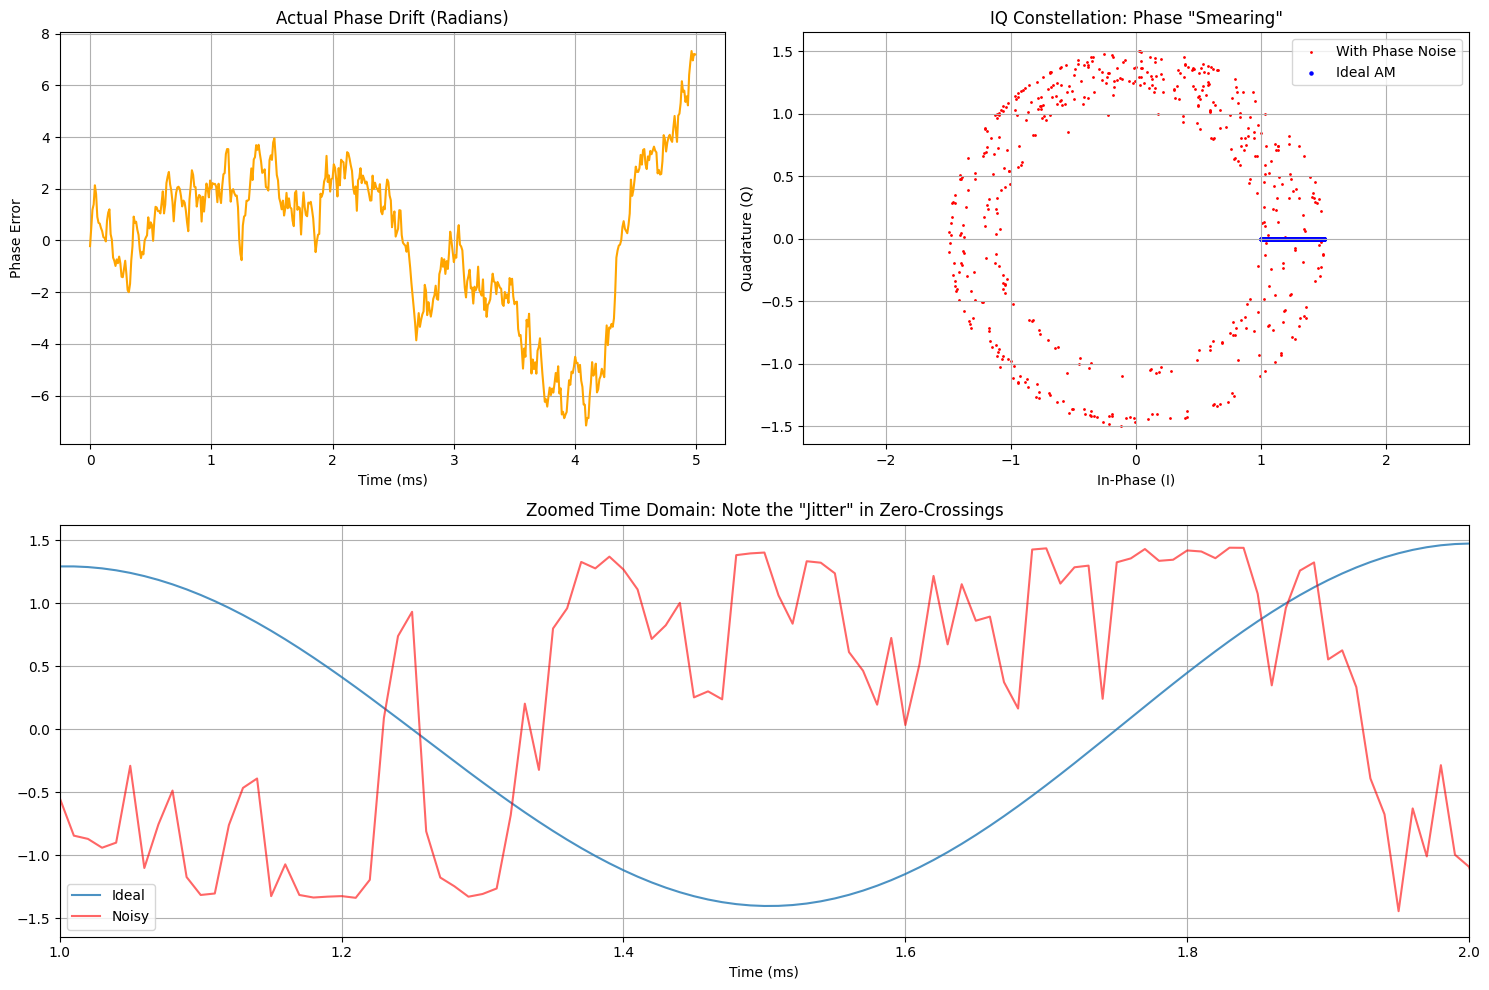

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Parameters
fs = 100000
t = np.arange(0, 0.005, 1/fs) # Shorter time window for better visibility
fc = 1000
fm = 100
mu = 0.5

# 2. Generate Signals
message = np.sin(2 * np.pi * fm * t)
# Generate a random walk for phase noise (Brownian Bridge style)
sigma = 0.5
phase_noise = np.cumsum(np.random.normal(0, sigma, len(t)))

# 3. Create Complex Envelopes (Analytic Signal)
# This allows us to see the 'Phasor' movement
am_ideal_complex = (1 + mu * message) * np.exp(1j * 2 * np.pi * fc * t)
am_noisy_complex = (1 + mu * message) * np.exp(1j * (2 * np.pi * fc * t + phase_noise))

# 4. Plotting
plt.figure(figsize=(15, 10))

# Subplot 1: Phase Noise Over Time
plt.subplot(2, 2, 1)
plt.plot(t*1000, phase_noise, color='orange')
plt.title('Actual Phase Drift (Radians)')
plt.xlabel('Time (ms)')
plt.ylabel('Phase Error')
plt.grid(True)

# Subplot 2: The IQ Constellation (The "Smear" Effect)
plt.subplot(2, 2, 2)
# Remove the carrier rotation to see just the modulation + noise
iq_ideal = (1 + mu * message)
iq_noisy = (1 + mu * message) * np.exp(1j * phase_noise)

plt.scatter(iq_noisy.real, iq_noisy.imag, s=1, color='red', label='With Phase Noise')
plt.scatter(iq_ideal, np.zeros_like(iq_ideal), s=5, color='blue', label='Ideal AM')
plt.title('IQ Constellation: Phase "Smearing"')
plt.xlabel('In-Phase (I)')
plt.ylabel('Quadrature (Q)')
plt.axis('equal')
plt.legend()
plt.grid(True)

# Subplot 3: Time Domain Zoom (The "Jitter")
plt.subplot(2, 1, 2)
plt.plot(t*1000, am_ideal_complex.real, label='Ideal', alpha=0.8)
plt.plot(t*1000, am_noisy_complex.real, label='Noisy', color='red', alpha=0.6)
plt.title('Zoomed Time Domain: Note the "Jitter" in Zero-Crossings')
plt.xlabel('Time (ms)')
plt.xlim(1, 2) # Zooming in on a 1ms window
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

1. The "Spectral Skirt" (PSD Analysis)

In a perfect system, the carrier is an infinitely thin line. In the PSD Analysis plot, you will see the red line (noisy) spreading out at the base of the carrier.


2. RMS Phase Error

The code calculates the Root Mean Square (RMS) Phase Error.



3. The Probability Density Function (Histogram)

The Histogram shows how the phase error is distributed.


4. Phase Drift (Temporal Analysis)

It shows the Random Walk.


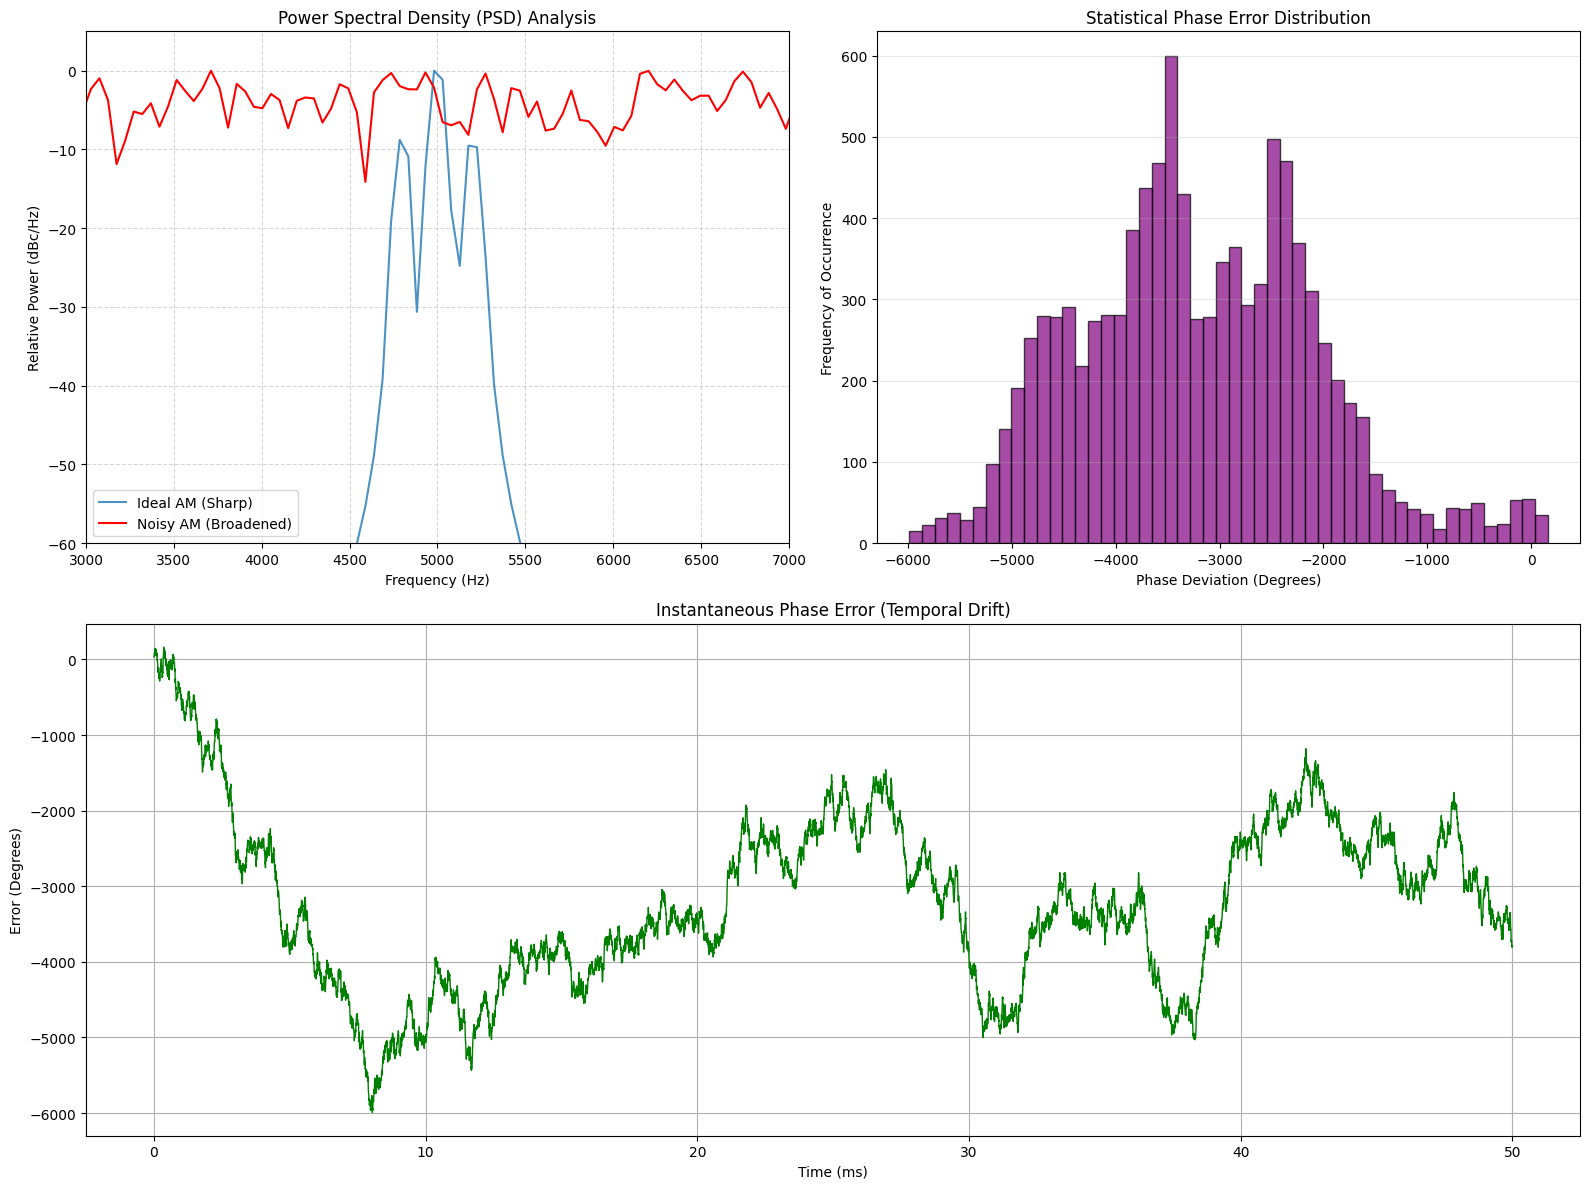

--- Phase Noise Measurements ---
RMS Phase Error: 3404.47 degrees
Peak-to-Peak Phase Jitter: 6156.79 degrees


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# 1. Simulation Parameters
fs = 200000          # Higher sampling for better PSD resolution
duration = 0.05      # 50ms simulation
t = np.arange(0, duration, 1/fs)
fc = 5000            # Carrier at 5kHz
fm = 200             # Message at 200Hz
mu = 0.7             # Modulation index

# 2. Signal Generation
message = np.sin(2 * np.pi * fm * t)
# Generate Phase Noise (Random Walk / Wiener Process)
# Increasing 'beta' increases the "close-in" phase noise
beta = 0.8
phase_noise = np.cumsum(np.random.normal(0, beta, len(t)))

# Ideal and Noisy AM Signals
am_ideal = (1 + mu * message) * np.cos(2 * np.pi * fc * t)
am_noisy = (1 + mu * message) * np.cos(2 * np.pi * fc * t + phase_noise)

# 3. Frequency Analysis (PSD in dBc/Hz)
# We use Welch's method for a smoother spectral estimate
freqs, psd_ideal = signal.welch(am_ideal, fs, nperseg=4096)
freqs, psd_noisy = signal.welch(am_noisy, fs, nperseg=4096)

# Normalize to Carrier Power (dBc)
psd_ideal_dbc = 10 * np.log10(psd_ideal / np.max(psd_ideal))
psd_noisy_dbc = 10 * np.log10(psd_noisy / np.max(psd_noisy))

# 4. Phase Error Measurement
# Difference between intended phase and actual phase
phase_error_deg = np.degrees(phase_noise)

# 5. Plotting the Analysis
fig = plt.figure(figsize=(16, 12))

# --- Plot 1: Power Spectral Density (The "Skirt") ---
ax1 = plt.subplot(2, 2, 1)
ax1.plot(freqs, psd_ideal_dbc, label='Ideal AM (Sharp)', alpha=0.8)
ax1.plot(freqs, psd_noisy_dbc, label='Noisy AM (Broadened)', color='red')
ax1.set_xlim(fc - 2000, fc + 2000)
ax1.set_ylim(-60, 5)
ax1.set_title('Power Spectral Density (PSD) Analysis')
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('Relative Power (dBc/Hz)')
ax1.grid(True, which='both', linestyle='--', alpha=0.5)
ax1.legend()

# --- Plot 2: Phase Error Distribution (Histogram) ---
ax2 = plt.subplot(2, 2, 2)
ax2.hist(phase_error_deg, bins=50, color='purple', alpha=0.7, edgecolor='black')
ax2.set_title('Statistical Phase Error Distribution')
ax2.set_xlabel('Phase Deviation (Degrees)')
ax2.set_ylabel('Frequency of Occurrence')
ax2.grid(axis='y', alpha=0.3)

# --- Plot 3: Instantaneous Phase Deviation over Time ---
ax3 = plt.subplot(2, 1, 2)
ax3.plot(t*1000, phase_error_deg, color='green', linewidth=1)
ax3.set_title('Instantaneous Phase Error (Temporal Drift)')
ax3.set_xlabel('Time (ms)')
ax3.set_ylabel('Error (Degrees)')
ax3.grid(True)

plt.tight_layout()
plt.show()

# 6. Numerical Measurements
rms_phase_error = np.sqrt(np.mean(phase_error_deg**2))
peak_to_peak_error = np.ptp(phase_error_deg)
print(f"--- Phase Noise Measurements ---")
print(f"RMS Phase Error: {rms_phase_error:.2f} degrees")
print(f"Peak-to-Peak Phase Jitter: {peak_to_peak_error:.2f} degrees")